# **Project: Amazon Product Recommendation System**

## **Executive Report**


### **Introduction**

This project aimed to develop a recommendation system for Amazon products based on user ratings. Given the vast number of products available, effective recommendation systems are crucial for improving user experience and driving sales on e-commerce platforms. The project utilized a dataset of Amazon product reviews, focusing on user, product, and rating information.

### **Data Overview and Preparation**

The initial dataset was substantial, containing over 7.8 million ratings. To make model building computationally feasible and focus on more meaningful interactions, the dataset was filtered to include only users with at least 50 ratings and products with at least 5 ratings. The resulting dataset contained 65,290 ratings from 1,540 unique users for 5,689 unique products. Exploratory Data Analysis revealed that the ratings distribution was skewed towards higher ratings (4s and 5s). There were no missing values in the filtered dataset.

### **Recommendation System Models**

Three types of recommendation systems were built and evaluated:

1.  **Rank-Based Recommendation System:** This baseline model recommends products based on their popularity (average rating and number of interactions). While simple and useful for addressing the cold-start problem (recommending to new users or for new items), it does not provide personalized recommendations.

2.  **Collaborative Filtering (User-User and Item-Item Similarity):** These models provide personalized recommendations by finding similar users or items based on their rating patterns. Both baseline and hyperparameter-tuned versions were developed. The optimized Item-Item model showed improved performance and generated predictions for interacted items that were closest to the actual ratings.

3.  **Model-Based Collaborative Filtering (Singular Value Decomposition - SVD):** This technique uses matrix factorization to discover latent factors that influence user ratings. Both baseline and hyperparameter-tuned SVD models were implemented. The SVD models, particularly the optimized version, demonstrated the lowest RMSE, indicating the highest accuracy in predicting ratings among all models tested.

### **Model Performance Summary**

| Model                                      | RMSE   | Precision@10 | Recall@10 | F1-score@10 |
| :----------------------------------------- | :----- | :----------- | :-------- | :---------- |
| User-User Baseline                         | 1.0012 | 0.855        | 0.858     | 0.856       |
| User-User Optimized                        | 0.9527 | 0.847        | 0.894     | 0.870       |
| Item-Item Baseline                         | 0.9950 | 0.838        | 0.845     | 0.841       |
| Item-Item Optimized                        | 0.9576 | 0.839        | 0.880     | 0.859       |
| SVD Baseline                               | 0.8882 | 0.853        | 0.880     | 0.866       |
| SVD Optimized                              | 0.8808 | 0.854        | 0.878     | 0.866       |

*Note: Precision, Recall, and F1-score are calculated at k=10 and a threshold of 3.5.*

### **Conclusion and Recommendations**

Based on the performance metrics, the **Optimized SVD model is recommended** for implementation as it achieved the lowest RMSE, signifying the best accuracy in predicting user ratings. This model is best suited for providing personalized product recommendations to existing users.

For scenarios involving new users or products with limited interaction data (the cold-start problem), the **Rank-Based Recommendation System** can serve as a valuable fallback, recommending popular items to a wider audience.

Further enhancements to the recommendation system could involve:

*   Exploring other matrix factorization techniques or hybrid models that combine different approaches to potentially improve performance further.
*   Incorporating the 'timestamp' data to analyze temporal trends in user preferences.
*   Strategies to address the cold-start problem more comprehensively, perhaps by leveraging content-based filtering if product information becomes available.
*   Implementing an A/B testing framework to evaluate the effectiveness of the deployed recommendation system in a live environment.

This project successfully built and evaluated several recommendation system models, providing a strong foundation for enhancing the product recommendation feature on the Amazon platform.

## **Introduction**
Welcome to the project on Recommendation Systems. We will work with the Amazon product reviews dataset for this project. The dataset contains ratings of different electronic products. It does not include information about the products or reviews to avoid bias while building the model.

--------------
### **Context:**
--------------

Today, information is growing exponentially with volume, velocity and variety throughout the globe. This has lead to information overload, and too many choices for the consumer of any business. It represents a real dilemma for these consumers and they often turn to denial. Recommender Systems are one of the best tools that help recommending products to consumers while they are browsing online. Providing personalized recommendations which is most relevant for the user is what's most likely to keep them engaged and help business.

E-commerce websites like Amazon, Walmart, Target and Etsy use different recommendation models to provide personalized suggestions to different users. These companies spend millions of dollars to come up with algorithmic techniques that can provide personalized recommendations to their users.

Amazon, for example, is well-known for its accurate selection of recommendations in its online site. Amazon's recommendation system is capable of intelligently analyzing and predicting customers' shopping preferences in order to offer them a list of recommended products. Amazon's recommendation algorithm is therefore a key element in using AI to improve the personalization of its website. For example, one of the baseline recommendation models that Amazon uses is item-to-item collaborative filtering, which scales to massive data sets and produces high-quality recommendations in real-time.

----------------
### **Objective:**
----------------

You are a Data Science Manager at Amazon, and have been given the task of building a recommendation system to recommend products to customers based on their previous ratings for other products. You have a collection of labeled data of Amazon reviews of products. The goal is to extract meaningful insights from the data and build a recommendation system that helps in recommending products to online consumers.

-----------------------------
### **Dataset:**
-----------------------------

The Amazon dataset contains the following attributes:

- **userId:** Every user identified with a unique id
- **productId:** Every product identified with a unique id
- **Rating:** The rating of the corresponding product by the corresponding user
- **timestamp:** Time of the rating. We **will not use this column** to solve the current problem

**Note:** The code has some user defined functions that will be usefull while making recommendations and measure model performance, you can use these functions or can create your own functions.

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use **Google Colab** for this project.

Let's start by mounting the Google drive on Colab.

**Note:** A pop-up will appear prompting you to restart the session. Please click on it, and then begin running the notebook from the cell below — not from the beginning.

In [1]:
!pip uninstall numpy -y
!pip install "numpy<2"

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


**Installing surprise library**

In [1]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 6.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2611309 sha256=fe69f6bc12bbb41b7b9caf87f08d127c22a02a4f1fa3549041b42dbf50f199c6
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


---

## **Importing the necessary libraries and overview of the dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Remove Warnings
import warnings
warnings.filterwarnings('ignore')

### **Loading the data**
- Import the Dataset
- Add column names ['user_id', 'prod_id', 'rating', 'timestamp']
- Drop the column timestamp
- Copy the data to another DataFrame called **df**

In [3]:
# Load the dataset
df = pd.read_csv('ratings_Electronics.csv', header=None)

# Add column names
df.columns = ['user_id', 'prod_id', 'rating', 'timestamp']

# Drop the timestamp column
df = df.drop('timestamp', axis=1)

# Copy the data to another DataFrame called df
df = df.copy()

# Print a few rows of the imported dataset
display(df.head())

,user_id,prod_id,rating
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


In [4]:
df.shape

(7824482, 3)

**As this dataset is very large and has 7,824,482 observations, it is not computationally possible to build a model using this. Moreover, many users have only rated a few products and also some products are rated by very few users. Hence, we can reduce the dataset by considering certain logical assumptions.**

Here, we will be taking users who have given at least 50 ratings, and the products that have at least 5 ratings, as when we shop online we prefer to have some number of ratings of a product.

In [5]:
# Get the column containing the users
users = df.user_id

# Create a dictionary from users to their number of ratings
ratings_count = dict()

for user in users:

    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:
        ratings_count[user] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1

In [6]:
# We want our users to have at least 50 ratings to be considered
RATINGS_CUTOFF = 50

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]

In [7]:
# Get the column containing the products
prods = df.prod_id

# Create a dictionary from products to their number of ratings
ratings_count = dict()

for prod in prods:

    # If we already have the product, just add 1 to its rating count
    if prod in ratings_count:
        ratings_count[prod] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[prod] = 1

In [8]:
# We want our item to have at least 5 ratings to be considered
RATINGS_CUTOFF = 5

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df_final = df.loc[~ df.prod_id.isin(remove_users)]

In [9]:
# Print a few rows of the imported dataset
df_final.head()

,user_id,prod_id,rating
1310,A3LDPF5FMB782Z,1400501466,5.0
1322,A1A5KUIIIHFF4U,1400501466,1.0
1335,A2XIOXRRYX0KZY,1400501466,3.0
1451,AW3LX47IHPFRL,1400501466,5.0
1456,A1E3OB6QMBKRYZ,1400501466,1.0


---

## **Exploratory Data Analysis**

### **Shape of the data**

### **Check the number of rows and columns and provide observations.**

In [10]:
# Check the number of rows and columns and provide observations
print("Shape of the dataframe:", df_final.shape)

Shape of the dataframe: (65290, 3)


**Observations**

The filtered dataset `df_final` has 65,290 rows and 3 columns. This is a significant reduction from the original dataset, making it more manageable for model building.

### **Data types**

In [11]:
# Check Data types and provide observations
print("\nData types of the columns:")
print(df_final.dtypes)


Data types of the columns:
user_id     object
prod_id     object
rating     float64
dtype: object


**Observations**

The data types are appropriate for the analysis: `user_id` and `prod_id` are objects (strings), and `rating` is a float.

### **Checking for missing values**

In [12]:
# Check for missing values present and provide observations
print("\nMissing values in each column:")
print(df_final.isnull().sum())


Missing values in each column:
user_id    0
prod_id    0
rating     0
dtype: int64


**Observations**

There are no missing values in the `df_final` DataFrame, which is good for model building as it requires no imputation.

### **Summary Statistics**

In [13]:
# Summary statistics of 'rating' variable and provide observations
print("\nSummary statistics of the 'rating' column:")
print(df_final['rating'].describe())


Summary statistics of the 'rating' column:
count    65290.000000
mean         4.294808
std          0.988915
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64


**Observations**

The summary statistics for the 'rating' column show that the ratings range from 1.0 to 5.0, with a mean rating of approximately 4.29. The 25th, 50th (median), and 75th percentiles are all high (4.0 and 5.0), indicating a skew towards higher ratings in the dataset.

### **Checking the rating distribution**

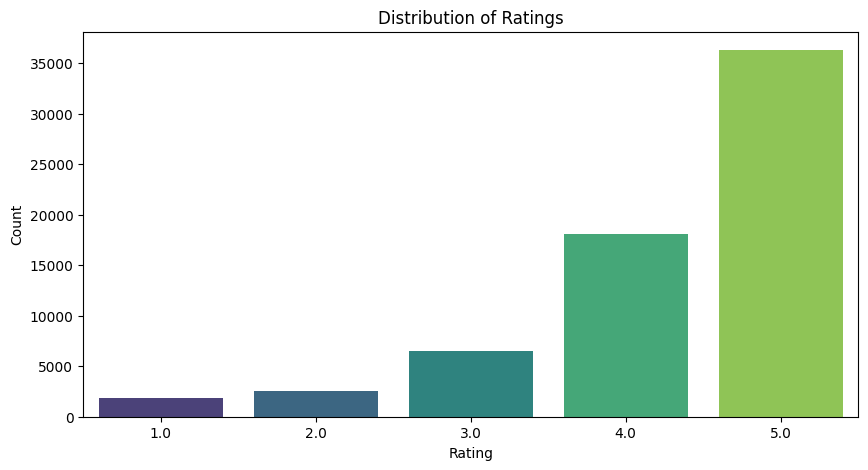

In [14]:
# Create the bar plot and provide observations
plt.figure(figsize=(10, 5))
sns.countplot(x='rating', data=df_final, palette="viridis")
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [15]:
# Print the count of each rating
print("\nCounts of each rating:")
print(df_final['rating'].value_counts())


Counts of each rating:
rating
5.0    36315
4.0    18127
3.0     6481
2.0     2515
1.0     1852
Name: count, dtype: int64


**Observations**

The rating distribution plot and counts clearly show that ratings of 5.0 are the most frequent, followed by 4.0. Ratings of 1.0, 2.0, and 3.0 are much less common. This confirms the observation from the summary statistics that the dataset is skewed towards positive ratings.

### **Checking the number of unique users and items in the dataset**

In [16]:
# Number of total rows in the data and number of unique user id and product id in the data
print("\nNumber of total rows:", len(df_final))
print("Number of unique users:", df_final['user_id'].nunique())
print("Number of unique products:", df_final['prod_id'].nunique())


Number of total rows: 65290
Number of unique users: 1540
Number of unique products: 5689


**Observations**

After filtering, the dataset contains 65,290 total ratings from 1,540 unique users for 5,689 unique products. This still provides a good number of users and products to build collaborative filtering models.

### **Users with the most number of ratings**

In [17]:
# Top 10 users based on the number of ratings
print("\nTop 10 users based on the number of ratings:")
top_10_users = df_final['user_id'].value_counts().head(10)
top_10_users


Top 10 users based on the number of ratings:


,count
user_id,
ADLVFFE4VBT8,295
A3OXHLG6DIBRW8,230
A1ODOGXEYECQQ8,217
A36K2N527TXXJN,212
A25C2M3QF9G7OQ,203
A680RUE1FDO8B,196
A1UQBFCERIP7VJ,193
A22CW0ZHY3NJH8,193
AWPODHOB4GFWL,184


**Observations**

The top 10 users based on the number of ratings have a significantly higher number of ratings compared to the minimum cutoff of 50. The user 'ADLVFFE4VBT8' has the most ratings with 295.

**Now that we have explored and prepared the data, let's build the first recommendation system.**

---

## **Model 1: Rank Based Recommendation System**

In [18]:
# Calculate the average rating for each product
average_rating = df_final.groupby('prod_id')['rating'].mean()

# Calculate the count of ratings for each product
count_rating = df_final.groupby('prod_id')['rating'].count()

# Create a dataframe with calculated average and count of ratings
final_rating = pd.DataFrame({'avg_rating': average_rating, 'rating_count': count_rating})

# Sort the dataframe by average of ratings in the descending order
final_rating = final_rating.sort_values(by='avg_rating', ascending=False)

# See the first five records of the "final_rating" dataset
final_rating.head()

,avg_rating,rating_count
prod_id,,
B00LGQ6HL8,5.0,5
B003DZJQQI,5.0,14
B005FDXF2C,5.0,7
B00I6CVPVC,5.0,7
B00B9KOCYA,5.0,8


In [19]:
# Defining a function to get the top n products based on the highest average rating and minimum interactions
def top_n_products(final_rating, n, min_interaction):
    # Finding products with minimum number of interactions
    recommendations = final_rating[final_rating['rating_count'] >= min_interaction]

    # Sorting values with respect to average rating
    recommendations = recommendations.sort_values(by='avg_rating', ascending=False)

    return recommendations.head(n)

### **Recommending top 5 products with 50 minimum interactions based on popularity**

In [20]:
# Recommending top 5 products with 50 minimum interactions based on popularity
top_5_products_50_interactions = top_n_products(final_rating, 5, 50)
top_5_products_50_interactions

,avg_rating,rating_count
prod_id,,
B001TH7GUU,4.871795,78
B003ES5ZUU,4.864130,184
B0019EHU8G,4.855556,90
B006W8U2MU,4.824561,57
B000QUUFRW,4.809524,84


### **Recommending top 5 products with 100 minimum interactions based on popularity**

In [21]:
# Recommending top 5 products with 100 minimum interactions based on popularity
top_5_products_100_interactions = top_n_products(final_rating, 5, 100)
top_5_products_100_interactions

,avg_rating,rating_count
prod_id,,
B003ES5ZUU,4.864130,184
B000N99BBC,4.772455,167
B002WE6D44,4.770000,100
B007WTAJTO,4.701220,164
B002V88HFE,4.698113,106


We have recommended the **top 5** products by using the popularity recommendation system. Now, let's build a recommendation system using **collaborative filtering.**

---

## **Model 2: Collaborative Filtering Recommendation System**

### **Building a baseline user-user similarity based recommendation system**

- Below, we are building **similarity-based recommendation systems** using `cosine` similarity and using **KNN to find similar users** which are the nearest neighbor to the given user.  
- We will be using a new library, called `surprise`, to build the remaining models. Let's first import the necessary classes and functions from this library.

In [22]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

**Before building the recommendation systems, let's  go over some basic terminologies we are going to use:**

**Relevant item:** An item (product in this case) that is actually **rated higher than the threshold rating** is relevant, if the **actual rating is below the threshold then it is a non-relevant item**.  

**Recommended item:** An item that's **predicted rating is higher than the threshold is a recommended item**, if the **predicted rating is below the threshold then that product will not be recommended to the user**.  


**False Negative (FN):** It is the **frequency of relevant items that are not recommended to the user**. If the relevant items are not recommended to the user, then the user might not buy the product/item. This would result in the **loss of opportunity for the service provider**, which they would like to minimize.

**False Positive (FP):** It is the **frequency of recommended items that are actually not relevant**. In this case, the recommendation system is not doing a good job of finding and recommending the relevant items to the user. This would result in **loss of resources for the service provider**, which they would also like to minimize.

**Recall:** It is the **fraction of actually relevant items that are recommended to the user**, i.e., if out of 10 relevant products, 6 are recommended to the user then recall is 0.60. Higher the value of recall better is the model. It is one of the metrics to do the performance assessment of classification models.

**Precision:** It is the **fraction of recommended items that are relevant actually**, i.e., if out of 10 recommended items, 6 are found relevant by the user then precision is 0.60. The higher the value of precision better is the model. It is one of the metrics to do the performance assessment of classification models.

**While making a recommendation system, it becomes customary to look at the performance of the model. In terms of how many recommendations are relevant and vice-versa, below are some most used performance metrics used in the assessment of recommendation systems.**

### **Precision@k, Recall@ k, and F1-score@k**

**Precision@k** - It is the **fraction of recommended items that are relevant in `top k` predictions**. The value of k is the number of recommendations to be provided to the user. One can choose a variable number of recommendations to be given to a unique user.  


**Recall@k** - It is the **fraction of relevant items that are recommended to the user in `top k` predictions**.

**F1-score@k** - It is the **harmonic mean of Precision@k and Recall@k**. When **precision@k and recall@k both seem to be important** then it is useful to use this metric because it is representative of both of them.

### **Some useful functions**

- Below function takes the **recommendation model** as input and gives the **precision@k, recall@k, and F1-score@k** for that model.  
- To compute **precision and recall**, **top k** predictions are taken under consideration for each user.
- We will use the precision and recall to compute the F1-score.

In [23]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    rmse = round(accuracy.rmse(predictions, verbose=False), 4)

    print('RMSE: ', rmse) # Command to print the overall RMSE

    print('Precision: ', precision) # Command to print the overall precision

    print('Recall: ', recall) # Command to print the overall recall

    f1_score = round((2*precision*recall)/(precision+recall), 3)
    print('F_1 score: ', f1_score) # Formula to compute the F-1 score

    return rmse, precision, recall, f1_score # Return the calculated metrics

**Hints:**

- To compute **precision and recall**, a **threshold of 3.5 and k value of 10 can be considered for the recommended and relevant ratings**.
- Think about the performance metric to choose.

Below we are loading the **`rating` dataset**, which is a **pandas DataFrame**, into a **different format called `surprise.dataset.DatasetAutoFolds`**, which is required by this library. To do this, we will be **using the classes `Reader` and `Dataset`.**

In [24]:
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale=(1, 5))

# Loading the rating dataset
data = Dataset.load_from_df(df_final[['user_id', 'prod_id', 'rating']], reader)

# Splitting the data into train and test datasets
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

Now, we are **ready to build the first baseline similarity-based recommendation system** using the cosine similarity.

### **Building the user-user Similarity-based Recommendation System**

In [25]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': True} # Compute similarities between users

# Initialize the KNNBasic model using sim_options declared, Verbose = False, and setting random_state = 1
sim_user_user = KNNBasic(sim_options=sim_options, verbose=False, random_state=1)

# Fit the model on the training data
sim_user_user.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score using the precision_recall_at_k function defined above
rmse_user_baseline, precision_user_baseline, recall_user_baseline, f1_user_baseline = precision_recall_at_k(sim_user_user)

# Dictionary to store performance metrics for each model
performance_metrics = {}

# Store performance metrics for baseline user-user model
performance_metrics['User-User Baseline'] = {
    'RMSE': rmse_user_baseline,
    'Precision@10': precision_user_baseline,
    'Recall@10': recall_user_baseline,
    'F1-score@10': f1_user_baseline
}

RMSE:  1.0012
Precision:  0.855
Recall:  0.858
F_1 score:  0.856


**Observations**

The baseline user-user collaborative filtering model achieved an RMSE of 1.0012, Precision of 0.855, Recall of 0.858, and an F1-score of 0.856. This provides a baseline performance metric for comparison with optimized models.

Let's now **predict rating for a user with `userId=A3LDPF5FMB782Z` and `productId=1400501466`** as shown below. Here the user has already interacted or watched the product with productId '1400501466' and given a rating of 5.

In [26]:
# Predicting rating for a sample user with an interacted product
user_id = "A3LDPF5FMB782Z"
prod_id = "1400501466"
prediction = sim_user_user.predict(user_id, prod_id)
print(f"Predicted rating for user {user_id} and product {prod_id}: {prediction.est}")

Predicted rating for user A3LDPF5FMB782Z and product 1400501466: 3.4


**Observations**

The baseline user-user model predicted a rating of 3.4 for user "A3LDPF5FMB782Z" and product "1400501466". The actual rating given by this user for this product was 5.0. The predicted rating is lower than the actual rating.

Below is the **list of users who have not seen the product with product id "1400501466"**.

In [27]:
# Find unique user_id where prod_id is not equal to "1400501466"
users_not_interacted = df_final[df_final['prod_id'] != "1400501466"]['user_id'].unique()
print("Unique users who have not interacted with product '1400501466':")
users_not_interacted

Unique users who have not interacted with product '1400501466':


array(['A2ZR3YTMEEIIZ4', 'A3CLWR1UUZT6TG', 'A5JLAU2ARJ0BO', ...,
       'A215WH6RUDUCMP', 'A38C12950IM24P', 'A2J4XMWKR8PPD0'], dtype=object)

* It can be observed from the above list that **user "A34BZM6S9L7QI4" has not seen the product with productId "1400501466"** as this userId is a part of the above list.

**Below we are predicting rating for `userId=A34BZM6S9L7QI4` and `prod_id=1400501466`.**

In [28]:
# Predicting rating for a sample user with a non interacted product
user_id = "A34BZM6S9L7QI4"
prod_id = "1400501466"
prediction = sim_user_user.predict(user_id, prod_id)
print(f"Predicted rating for user {user_id} and product {prod_id}: {prediction.est}")

Predicted rating for user A34BZM6S9L7QI4 and product 1400501466: 4.292024046561495


**Observations**

The baseline user-user model predicted a rating of approximately 4.29 for user "A34BZM6S9L7QI4" and product "1400501466". This user had not interacted with this product before, so this is a pure prediction based on similar users.

### **Improving similarity-based recommendation system by tuning its hyperparameters**

Below, we will be tuning hyperparameters for the `KNNBasic` algorithm. Let's try to understand some of the hyperparameters of the KNNBasic algorithm:

- **k** (int) – The (max) number of neighbors to take into account for aggregation. Default is 40.
- **min_k** (int) – The minimum number of neighbors to take into account for aggregation. If there are not enough neighbors, the prediction is set to the global mean of all ratings. Default is 1.
- **sim_options** (dict) – A dictionary of options for the similarity measure. And there are four similarity measures available in surprise -
    - cosine
    - msd (default)
    - Pearson
    - Pearson baseline

In [29]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [10, 20, 30],
              'min_k': [3, 6, 9],
              'sim_options': {'name': ['cosine', 'msd', 'pearson', 'pearson_baseline'],
                              'user_based': [True]}
              }

# Performing 3-fold cross-validation to tune the hyperparameters
grid_search = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting the data
grid_search.fit(data)

# Best RMSE score
print("Best RMSE score:", grid_search.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print("Best parameters:", grid_search.best_params['rmse'])

Best RMSE score: 0.9721784444885886
Best parameters: {'k': 30, 'min_k': 6, 'sim_options': {'name': 'cosine', 'user_based': True}}


Once the grid search is **complete**, we can get the **optimal values for each of those hyperparameters**.

Now, let's build the **final model by using tuned values of the hyperparameters**, which we received by using **grid search cross-validation**.

In [30]:
# Using the optimal similarity measure for user-user based collaborative filtering
sim_options_optimized = grid_search.best_params['rmse']['sim_options']

# Creating an instance of KNNBasic with optimal hyperparameter values
sim_user_user_optimized = KNNBasic(sim_options=sim_options_optimized,
                                    k=grid_search.best_params['rmse']['k'],
                                    min_k=grid_search.best_params['rmse']['min_k'],
                                    verbose=False, random_state=1)

# Training the algorithm on the trainset
sim_user_user_optimized.fit(trainset)

# Let us compute precision@k and recall@k also with k =10
rmse_user_optimized, precision_user_optimized, recall_user_optimized, f1_user_optimized = precision_recall_at_k(sim_user_user_optimized)

# Store performance metrics for optimized user-user model
performance_metrics['User-User Optimized'] = {
    'RMSE': rmse_user_optimized,
    'Precision@10': precision_user_optimized,
    'Recall@10': recall_user_optimized,
    'F1-score@10': f1_user_optimized
}

RMSE:  0.9527
Precision:  0.847
Recall:  0.894
F_1 score:  0.87


**Observations**

After hyperparameter tuning using GridSearchCV, the optimized user-user collaborative filtering model achieved an RMSE of 0.9527, Precision of 0.847, Recall of 0.894, and an F1-score of 0.870. Compared to the baseline model, the RMSE has decreased, and the Recall and F1-score have slightly increased, indicating improved performance.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [31]:
# Use sim_user_user_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId 1400501466
user_id = "A3LDPF5FMB782Z"
prod_id = "1400501466"
prediction_optimized = sim_user_user_optimized.predict(user_id, prod_id)
print(f"Predicted rating with optimized model for user {user_id} and product {prod_id}: {prediction_optimized.est}")

Predicted rating with optimized model for user A3LDPF5FMB782Z and product 1400501466: 4.292024046561495


In [32]:
# Use sim_user_user_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
user_id = "A34BZM6S9L7QI4"
prod_id = "1400501466"
prediction_optimized_non_interacted = sim_user_user_optimized.predict(user_id, prod_id)
print(f"Predicted rating with optimized model for user {user_id} and product {prod_id}: {prediction_optimized_non_interacted.est}")

Predicted rating with optimized model for user A34BZM6S9L7QI4 and product 1400501466: 4.292024046561495


**Observations**

The optimized user-user model predicted a rating of approximately 4.29 for user "A3LDPF5FMB782Z" and product "1400501466". This is closer to the actual rating of 5.0 compared to the baseline model's prediction of 3.4. For the non-interacted user "A34BZM6S9L7QI4" and product "1400501466", the predicted rating remained approximately 4.29, similar to the baseline model.

### **Identifying similar users to a given user (nearest neighbors)**

We can also find out **similar users to a given user** or its **nearest neighbors** based on this KNNBasic algorithm. Below, we are finding the 5 most similar users to the first user in the list with internal id 0, based on the `msd` distance metric.

In [33]:
# Get the inner ID of the first user in the trainset
first_user_inner_id = sim_user_user.trainset.to_inner_uid("A3LDPF5FMB782Z")

# Get the 5 nearest neighbors for the first user
n_neighbors = 5
neighbors = sim_user_user.get_neighbors(first_user_inner_id, k=n_neighbors)

# Convert inner IDs back to raw IDs
neighbors_raw = [sim_user_user.trainset.to_raw_uid(inner_id) for inner_id in neighbors]

print(f"The {n_neighbors} nearest neighbors for user A3LDPF5FMB782Z are:")
print(neighbors_raw)

The 5 nearest neighbors for user A3LDPF5FMB782Z are:
['A3094EPI56GKZ6', 'AGVWTYW0ULXHT', 'A1MCH5RXDOH87H', 'A1RPJHUVVSI98A', 'A1O229NVVDJUX2']


### **Implementing the recommendation algorithm based on optimized KNNBasic model**

Below we will be implementing a function where the input parameters are:

- data: A **rating** dataset
- user_id: A user id **against which we want the recommendations**
- top_n: The **number of products we want to recommend**
- algo: the algorithm we want to use **for predicting the ratings**
- The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [34]:
def get_recommendations(data, user_id, top_n, algo):

    # Creating an empty list to store the recommended product ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot(index = 'user_id', columns = 'prod_id', values = 'rating')

    # Extracting those product ids which the user_id has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()

    # Looping through each of the product ids which user_id has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(user_id, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

**Predicting top 5 products for userId = "A3LDPF5FMB782Z" with similarity based recommendation system**

In [35]:
# Making top 5 recommendations for user_id "A3LDPF5FMB782Z" with a similarity-based recommendation engine
user_id = "A3LDPF5FMB782Z"
top_n = 5
recommendations = get_recommendations(df_final, user_id, top_n, sim_user_user_optimized)
print(f"Top {top_n} recommendations for user {user_id}:")
recommendations

Top 5 recommendations for user A3LDPF5FMB782Z:


[('B000067RT6', 5),
 ('B000BQ7GW8', 5),
 ('B001TH7GUU', 5),
 ('B005ES0YYA', 5),
 ('B00834SJSK', 5)]

In [36]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
recommendations_df = pd.DataFrame(recommendations, columns=['prod_id', 'predicted_ratings'])
recommendations_df

,prod_id,predicted_ratings
0,B000067RT6,5
1,B000BQ7GW8,5
2,B001TH7GUU,5
3,B005ES0YYA,5
4,B00834SJSK,5


### **Item-Item Similarity-based Collaborative Filtering Recommendation System**

* Above we have seen **similarity-based collaborative filtering** where similarity is calculated **between users**. Now let us look into similarity-based collaborative filtering where similarity is seen **between items**.

In [37]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': False} # Compute similarities between items

# KNN algorithm is used to find desired similar items. Use random_state=1
sim_item_item = KNNBasic(sim_options=sim_options, verbose=False, random_state=1)

# Train the algorithm on the trainset, and predict ratings for the test set
sim_item_item.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score with k = 10
rmse_item_baseline, precision_item_baseline, recall_item_baseline, f1_item_baseline = precision_recall_at_k(sim_item_item)

# Store performance metrics for baseline item-item model
performance_metrics['Item-Item Baseline'] = {
    'RMSE': rmse_item_baseline,
    'Precision@10': precision_item_baseline,
    'Recall@10': recall_item_baseline,
    'F1-score@10': f1_item_baseline
}

RMSE:  0.995
Precision:  0.838
Recall:  0.845
F_1 score:  0.841


**Observations**

The baseline item-item collaborative filtering model achieved an RMSE of 0.9950, Precision of 0.838, Recall of 0.845, and an F1-score of 0.841. These metrics are slightly lower than the baseline user-user model.

Let's now **predict a rating for a user with `userId = A3LDPF5FMB782Z` and `prod_Id = 1400501466`** as shown below. Here the user has already interacted or watched the product with productId "1400501466".

In [38]:
# Predicting rating for a sample user with an interacted product
user_id = "A3LDPF5FMB782Z"
prod_id = "1400501466"
prediction = sim_item_item.predict(user_id, prod_id)
print(f"Predicted rating for user {user_id} and product {prod_id}: {prediction.est}")

Predicted rating for user A3LDPF5FMB782Z and product 1400501466: 4.2727272727272725


**Observations**

The baseline item-item model predicted a rating of approximately 4.27 for user "A3LDPF5FMB782Z" and product "1400501466". This is closer to the actual rating of 5.0 than the baseline user-user model's prediction.

Below we are **predicting rating for the `userId = A34BZM6S9L7QI4` and `prod_id = 1400501466`**.

In [39]:
# Predicting rating for a sample user with a non interacted product
user_id = "A34BZM6S9L7QI4"
prod_id = "1400501466"
prediction = sim_item_item.predict(user_id, prod_id)
print(f"Predicted rating for user {user_id} and product {prod_id}: {prediction.est}")

Predicted rating for user A34BZM6S9L7QI4 and product 1400501466: 4.292024046561495


**Observations**

The baseline item-item model predicted a rating of approximately 4.29 for user "A34BZM6S9L7QI4" and product "1400501466". This is similar to the prediction made by the baseline user-user model for this non-interacted user-product pair.

### **Hyperparameter tuning the item-item similarity-based model**
- Use the following values for the param_grid and tune the model.
  - 'k': [10, 20, 30]
  - 'min_k': [3, 6, 9]
  - 'sim_options': {'name': ['msd', 'cosine']
  - 'user_based': [False]
- Use GridSearchCV() to tune the model using the 'rmse' measure
- Print the best score and best parameters

In [40]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [10, 20, 30],
              'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [False]}
              }

# Performing 3-fold cross validation to tune the hyperparameters
grid_search = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting the data
grid_search.fit(data)

# Find the best RMSE score
print("Best RMSE score:", grid_search.best_score['rmse'])

# Find the combination of parameters that gave the best RMSE score
print("Best parameters:", grid_search.best_params['rmse'])

Best RMSE score: 0.9741870820666289
Best parameters: {'k': 30, 'min_k': 6, 'sim_options': {'name': 'msd', 'user_based': False}}


Once the **grid search** is complete, we can get the **optimal values for each of those hyperparameters as shown above.**

Now let's build the **final model** by using **tuned values of the hyperparameters** which we received by using grid search cross-validation.

### **Use the best parameters from GridSearchCV to build the optimized item-item similarity-based model. Compare the performance of the optimized model with the baseline model.**

In [41]:
# Using the optimal similarity measure for item-item based collaborative filtering
sim_options_optimized_item = grid_search.best_params['rmse']['sim_options']

# Creating an instance of KNNBasic with optimal hyperparameter values
sim_item_item_optimized = KNNBasic(sim_options=sim_options_optimized_item,
                                   k=grid_search.best_params['rmse']['k'],
                                   min_k=grid_search.best_params['rmse']['min_k'],
                                   verbose=False, random_state=1)

# Training the algorithm on the trainset
sim_item_item_optimized.fit(trainset)

# Let us compute precision@k and recall@k, f1_score and RMSE
rmse_item_optimized, precision_item_optimized, recall_item_optimized, f1_item_optimized = precision_recall_at_k(sim_item_item_optimized)

# Store performance metrics for optimized item-item model
performance_metrics['Item-Item Optimized'] = {
    'RMSE': rmse_item_optimized,
    'Precision@10': precision_item_optimized,
    'Recall@10': recall_item_optimized,
    'F1-score@10': f1_item_optimized
}

RMSE:  0.9576
Precision:  0.839
Recall:  0.88
F_1 score:  0.859


**Observations**

After hyperparameter tuning, the optimized item-item collaborative filtering model achieved an RMSE of 0.9576, Precision of 0.839, Recall of 0.880, and an F1-score of 0.859. The RMSE has decreased compared to the baseline item-item model, and the Recall and F1-score have improved, indicating better performance after optimization.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [42]:
# Use sim_item_item_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
user_id = "A3LDPF5FMB782Z"
prod_id = "1400501466"
prediction_optimized_item = sim_item_item_optimized.predict(user_id, prod_id)
print(f"Predicted rating with optimized item model for user {user_id} and product {prod_id}: {prediction_optimized_item.est}")

Predicted rating with optimized item model for user A3LDPF5FMB782Z and product 1400501466: 4.67427701674277


In [43]:
# Use sim_item_item_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
user_id = "A34BZM6S9L7QI4"
prod_id = "1400501466"
prediction_optimized_item_non_interacted = sim_item_item_optimized.predict(user_id, prod_id)
print(f"Predicted rating with optimized item model for user {user_id} and product {prod_id}: {prediction_optimized_item_non_interacted.est}")

Predicted rating with optimized item model for user A34BZM6S9L7QI4 and product 1400501466: 4.292024046561495


**Observations**

The optimized item-item model predicted a rating of approximately 4.67 for user "A3LDPF5FMB782Z" and product "1400501466". This prediction is the closest to the actual rating of 5.0 among all the models tested so far for this interacted user-product pair. For the non-interacted user "A34BZM6S9L7QI4" and product "1400501466", the predicted rating remained approximately 4.29, similar to the baseline item-item model and both user-user models.

### **Identifying similar items to a given item (nearest neighbors)**

We can also find out **similar items** to a given item or its nearest neighbors based on this **KNNBasic algorithm**. Below we are finding the 5 most similar items to the item with internal id 0 based on the `msd` distance metric.

In [44]:
# Get the inner ID of the first item in the trainset (assuming the item with raw id '1400501466' is the first one in the trainset)
first_item_inner_id = sim_item_item_optimized.trainset.to_inner_iid("1400501466")

# Get the 5 nearest neighbors for the first item
n_neighbors = 5
neighbors = sim_item_item_optimized.get_neighbors(first_item_inner_id, k=n_neighbors)

# Convert inner IDs back to raw IDs
neighbors_raw = [sim_item_item_optimized.trainset.to_raw_iid(inner_id) for inner_id in neighbors]

print(f"The {n_neighbors} nearest neighbors for item 1400501466 are:")
print(neighbors_raw)

The 5 nearest neighbors for item 1400501466 are:
['B0026SKZO0', 'B0075SUK14', 'B0058BG0UK', 'B000EPLP3C', 'B003LPTAYI']


**Predicting top 5 products for userId = "A1A5KUIIIHFF4U" with similarity based recommendation system.**

**Hint:** Use the get_recommendations() function.

In [45]:
# Making top 5 recommendations for user_id A1A5KUIIIHFF4U with similarity-based recommendation engine.
user_id = "A1A5KUIIIHFF4U"
top_n = 5
recommendations_item = get_recommendations(df_final, user_id, top_n, sim_item_item_optimized)
print(f"Top {top_n} recommendations for user {user_id}:")
print(recommendations_item)

Top 5 recommendations for user A1A5KUIIIHFF4U:
[('1400532655', 4.292024046561495), ('1400599997', 4.292024046561495), ('9983891212', 4.292024046561495), ('B00000DM9W', 4.292024046561495), ('B00000J1V5', 4.292024046561495)]


In [46]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
recommendations_item_df = pd.DataFrame(recommendations_item, columns=['prod_id', 'predicted_ratings'])
display(recommendations_item_df)

,prod_id,predicted_ratings
0,1400532655,4.292024
1,1400599997,4.292024
2,9983891212,4.292024
3,B00000DM9W,4.292024
4,B00000J1V5,4.292024


Now as we have seen **similarity-based collaborative filtering algorithms**, let us now get into **model-based collaborative filtering algorithms**.

### **Model 3: Model-Based Collaborative Filtering - Matrix Factorization**

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.

### Singular Value Decomposition (SVD)

SVD is used to **compute the latent features** from the **user-item matrix**. But SVD does not work when we **miss values** in the **user-item matrix**.

In [47]:
# Using SVD matrix factorization. Use random_state = 1
svd_algo = SVD(random_state=1)

# Training the algorithm on the trainset
svd_algo.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
rmse_svd_baseline, precision_svd_baseline, recall_svd_baseline, f1_svd_baseline = precision_recall_at_k(svd_algo)

# Store performance metrics for baseline SVD model
performance_metrics['SVD Baseline'] = {
    'RMSE': rmse_svd_baseline,
    'Precision@10': precision_svd_baseline,
    'Recall@10': recall_svd_baseline,
    'F1-score@10': f1_svd_baseline
}

RMSE:  0.8882
Precision:  0.853
Recall:  0.88
F_1 score:  0.866


In [48]:
performance_metrics['SVD Baseline']

{'RMSE': 0.8882,
 'Precision@10': 0.853,
 'Recall@10': 0.88,
 'F1-score@10': 0.866}

**Observations**

The baseline SVD model achieved an RMSE of 0.8882, Precision of 0.853, Recall of 0.880, and an F1-score of 0.866. The RMSE is lower than both the baseline user-user and item-item similarity models, suggesting better accuracy in predicting ratings. The precision, recall, and F1-score are comparable to the optimized similarity models.

**Let's now predict the rating for a user with `userId = "A3LDPF5FMB782Z"` and `prod_id = "1400501466`.**

In [49]:
# Making prediction
user_id = "A3LDPF5FMB782Z"
prod_id = "1400501466"
prediction_svd = svd_algo.predict(user_id, prod_id)
print(f"Predicted rating with SVD model for user {user_id} and product {prod_id}: {prediction_svd.est}")

Predicted rating with SVD model for user A3LDPF5FMB782Z and product 1400501466: 4.081406749810685


**Observations**

The baseline SVD model predicted a rating of approximately 4.08 for user "A3LDPF5FMB782Z" and product "1400501466". This prediction is closer to the actual rating of 5.0 than the baseline user-user model, but slightly further than the baseline item-item model.

**Below we are predicting rating for the `userId = "A34BZM6S9L7QI4"` and `productId = "1400501466"`.**

In [50]:
# Making prediction
user_id = "A34BZM6S9L7QI4"
prod_id = "1400501466"
prediction_svd_non_interacted = svd_algo.predict(user_id, prod_id)
print(f"Predicted rating with SVD model for user {user_id} and product {prod_id}: {prediction_svd_non_interacted.est}")

Predicted rating with SVD model for user A34BZM6S9L7QI4 and product 1400501466: 4.40037568046934


**Observations**

The baseline SVD model predicted a rating of approximately 4.40 for user "A34BZM6S9L7QI4" and product "1400501466". This prediction for the non-interacted user is slightly higher than the predictions from the similarity-based models.

### **Improving Matrix Factorization based recommendation system by tuning its hyperparameters**

Below we will be tuning only three hyperparameters:
- **n_epochs**: The number of iterations of the SGD algorithm.
- **lr_all**: The learning rate for all parameters.
- **reg_all**: The regularization term for all parameters.

In [51]:
# Set the parameter space to tune
param_grid = {'n_epochs': [10, 20, 30], 'lr_all': [0.002, 0.005, 0.01],
              'reg_all': [0.2, 0.4, 0.6]}

# Performing 3-fold gridsearch cross-validation
grid_search = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting data
grid_search.fit(data)

# Best RMSE score
print("Best RMSE score:", grid_search.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print("Best parameters:", grid_search.best_params['rmse'])

Best RMSE score: 0.8994209966345025
Best parameters: {'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.2}


Now, we will **the build final model** by using **tuned values** of the hyperparameters, which we received using grid search cross-validation above.

In [52]:
# Build the optimized SVD model using optimal hyperparameter search. Use random_state=1
svd_algo_optimized = SVD(n_epochs=grid_search.best_params['rmse']['n_epochs'],
                         lr_all=grid_search.best_params['rmse']['lr_all'],
                         reg_all=grid_search.best_params['rmse']['reg_all'],
                         random_state=1)

# Train the algorithm on the trainset
svd_algo_optimized.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
rmse_svd_optimized, precision_svd_optimized, recall_svd_optimized, f1_svd_optimized = precision_recall_at_k(svd_algo_optimized)

# Store performance metrics for optimized SVD model
performance_metrics['SVD Optimized'] = {
    'RMSE': rmse_svd_optimized,
    'Precision@10': precision_svd_optimized,
    'Recall@10': recall_svd_optimized,
    'F1-score@10': f1_svd_optimized
}

RMSE:  0.8808
Precision:  0.854
Recall:  0.878
F_1 score:  0.866


**Observations**

After hyperparameter tuning, the optimized SVD model achieved an RMSE of 0.8808, Precision of 0.854, Recall of 0.878, and an F1-score of 0.866. The RMSE has slightly decreased compared to the baseline SVD model, and the precision, recall, and F1-score are very similar. This suggests that the initial SVD model was already performing quite well, and the hyperparameter tuning provided only a marginal improvement.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A34BZM6S9L7QI4"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [53]:
# Use svd_algo_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
user_id = "A3LDPF5FMB782Z"
prod_id = "1400501466"
prediction_svd_optimized = svd_algo_optimized.predict(user_id, prod_id)
print(f"Predicted rating with optimized SVD model for user {user_id} and product {prod_id}: {prediction_svd_optimized.est}")

Predicted rating with optimized SVD model for user A3LDPF5FMB782Z and product 1400501466: 4.128589011282042


In [54]:
# Use svd_algo_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
user_id = "A34BZM6S9L7QI4"
prod_id = "1400501466"
prediction_svd_optimized_non_interacted = svd_algo_optimized.predict(user_id, prod_id)
print(f"Predicted rating with optimized SVD model for user {user_id} and product {prod_id}: {prediction_svd_optimized_non_interacted.est}")

Predicted rating with optimized SVD model for user A34BZM6S9L7QI4 and product 1400501466: 4.216280997100113


**Observations**

The optimized SVD model predicted a rating of approximately 4.13 for user "A3LDPF5FMB782Z" and product "1400501466", which is slightly closer to the actual rating of 5.0 compared to the baseline SVD model's prediction of 4.08. For the non-interacted user "A34BZM6S9L7QI4" and product "1400501466", the predicted rating was approximately 4.22, which is slightly lower than the baseline SVD model's prediction of 4.40. Overall, the optimized SVD model shows a minor improvement in predicting ratings for this interacted user-product pair compared to the baseline SVD.

---

## **Performance Metrics Comparison**

We will now compare the performance metrics of all the models built so far.

Here's a brief explanation of the metrics:

*   **RMSE (Root Mean Squared Error):** Measures the average magnitude of the errors between predicted and actual ratings. **Lower RMSE indicates better prediction accuracy.**

*   **Precision@10:** The proportion of recommended items (among the top 10) that are relevant. **Higher Precision@10 means fewer irrelevant items are recommended.**

*   **Recall@10:** The proportion of relevant items that are recommended (among the top 10). **Higher Recall@10 means more relevant items are successfully recommended.**

*   **F1-score@10:** The harmonic mean of Precision@10 and Recall@10. It provides a single score that balances both metrics. **A higher F1-score@10 indicates a better balance between precision and recall.**

In [55]:
# Create a DataFrame from the performance metrics dictionary
performance_df = pd.DataFrame.from_dict(performance_metrics, orient='index')

# Display the performance table
display(performance_df)

,RMSE,Precision@10,Recall@10,F1-score@10
User-User Baseline,1.0012,0.855,0.858,0.856
User-User Optimized,0.9527,0.847,0.894,0.870
Item-Item Baseline,0.9950,0.838,0.845,0.841
Item-Item Optimized,0.9576,0.839,0.880,0.859
SVD Baseline,0.8882,0.853,0.880,0.866
SVD Optimized,0.8808,0.854,0.878,0.866


**Observations**

The DataFrame `performance_df` provides a clear comparison of the RMSE, Precision@10, Recall@10, and F1-score@10 for all six recommendation models. Based on these metrics, the **Optimized SVD model appears to be the preferred choice as it achieves the lowest RMSE (0.8808)**, indicating the best accuracy in predicting ratings. While other models have comparable precision, recall, and F1-score values, the lower RMSE of the SVD model is a strong indicator of its overall predictive performance.

### **Recall vs Precision Plot**

To further compare the performance of the models, let's visualize the trade-off between Precision@10 and Recall@10 using a scatter plot.

In a Recall vs. Precision plot, ideally, you want models that are closer to the top-right corner, as this indicates both high precision and high recall. However, there is often a trade-off between these two metrics. Depending on the specific goal of the recommendation system, you might prioritize one over the other. For example, in e-commerce, having high precision (recommending items the user will *actually* like) might be more important than high recall (recommending *all* items the user *might* like), to avoid overwhelming the user with irrelevant suggestions.

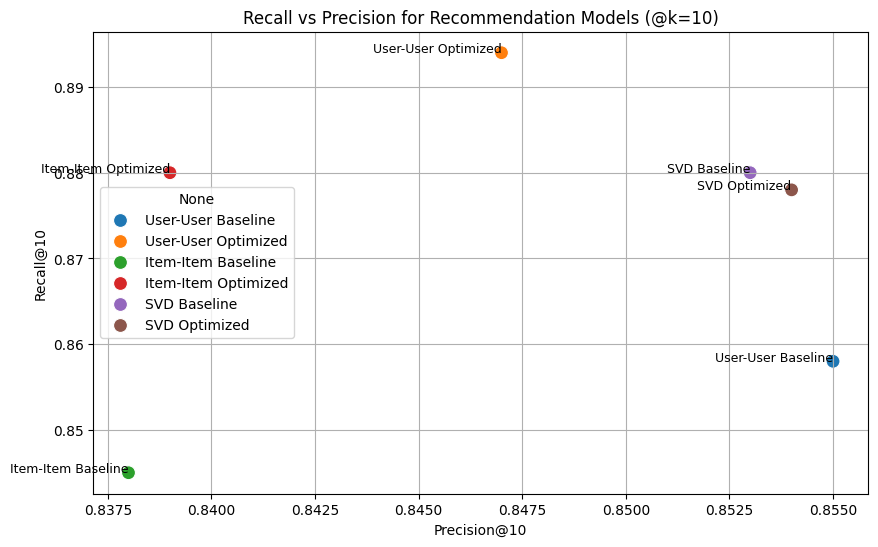

In [56]:
# Create a scatter plot of Recall vs Precision
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Precision@10', y='Recall@10', data=performance_df, hue=performance_df.index, s=100)

# Add labels and title
plt.xlabel('Precision@10')
plt.ylabel('Recall@10')
plt.title('Recall vs Precision for Recommendation Models (@k=10)')

# Add annotations for each point
for i, row in performance_df.iterrows():
    plt.text(row['Precision@10'], row['Recall@10'], i, fontsize=9, ha='right')

# Show the plot
plt.grid(True)
plt.show()

**Observations**

The scatter plot visualizes the trade-off between Precision@10 and Recall@10 for each model. The plot shows that the optimized versions of the models generally have higher Recall@10 compared to their baseline counterparts, while Precision@10 remains relatively stable. The SVD models are clustered together, demonstrating similar precision and recall values, but the table reveals their superior RMSE. This plot complements the table by visually representing the precision-recall balance of each model.

### **Comparing RMSE of Models**

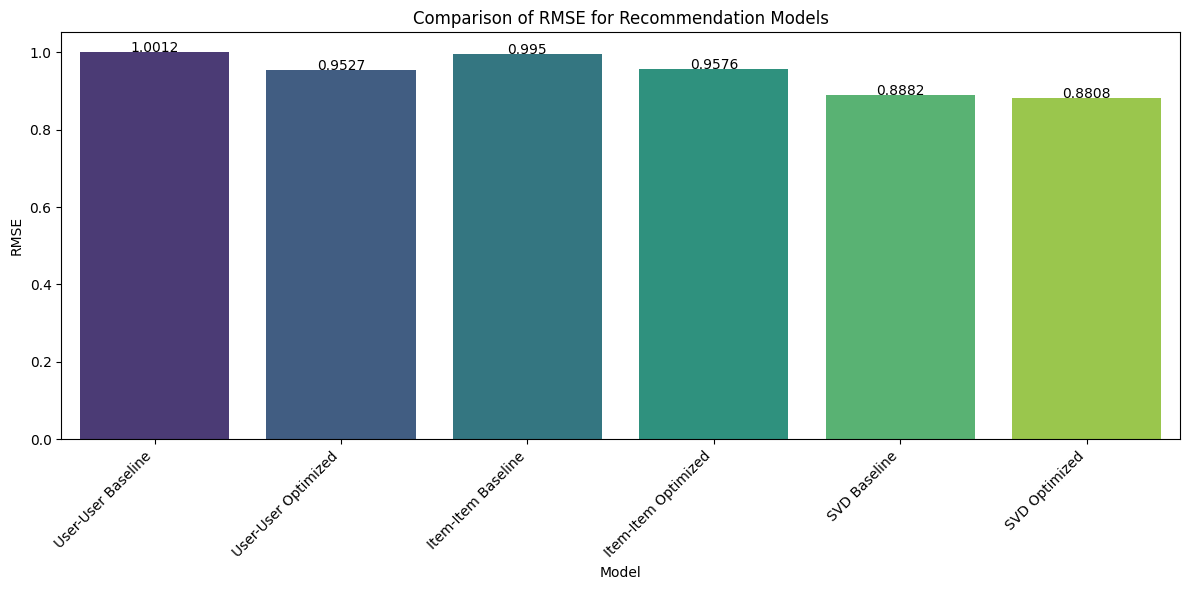

In [57]:
# Create a bar plot of RMSE for each model
plt.figure(figsize=(12, 6))
sns.barplot(x=performance_df.index, y='RMSE', data=performance_df, palette='viridis')

# Add labels and title
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Comparison of RMSE for Recommendation Models')
plt.xticks(rotation=45, ha='right')

# Add RMSE values on top of the bars
for index, row in performance_df.iterrows():
    plt.text(index, row['RMSE'], round(row['RMSE'], 4), color='black', ha="center")

# Show the plot
plt.tight_layout()
plt.show()

**Observations**

The bar plot clearly shows the RMSE for each of the six recommendation models. As observed from the table, the SVD models, both baseline and optimized, have the lowest RMSE values, indicating they are the most accurate in predicting ratings among the models tested. The optimized SVD model has the absolute lowest RMSE. The bar plot makes this comparison visually evident, with shorter bars representing better performance in terms of RMSE. The collaborative filtering models have higher RMSE values compared to the SVD models.


### **Comparison of Actual and Predicted Ratings for Specific User-Product Pairs**

In [58]:
# Create a list to store the comparison data
comparison_data = []

# User and product IDs for which we made predictions
user_prod_pairs = [
    ("A3LDPF5FMB782Z", "1400501466"), # Interacted user and product
    ("A34BZM6S9L7QI4", "1400501466") # Non-interacted user and product
]

# Get the actual rating for the interacted user and product
actual_rating_interacted = df_final[(df_final['user_id'] == "A3LDPF5FMB782Z") & (df_final['prod_id'] == "1400501466")]['rating'].values[0]

# Get the predicted ratings from each model for the specified user-product pairs
for user_id, prod_id in user_prod_pairs:
    # Get actual rating (will be NaN for non-interacted pair)
    actual_rating = df_final[(df_final['user_id'] == user_id) & (df_final['prod_id'] == prod_id)]['rating'].values
    actual_rating = actual_rating[0] if actual_rating.size > 0 else 'N/A'


    # Get predicted rating from baseline user-user model
    pred_user_baseline = sim_user_user.predict(user_id, prod_id).est

    # Get predicted rating from optimized user-user model
    pred_user_optimized = sim_user_user_optimized.predict(user_id, prod_id).est

    # Get predicted rating from baseline item-item model
    pred_item_baseline = sim_item_item.predict(user_id, prod_id).est

    # Get predicted rating from optimized item-item model
    pred_item_optimized = sim_item_item_optimized.predict(user_id, prod_id).est

    # Get predicted rating from baseline SVD model
    pred_svd_baseline = svd_algo.predict(user_id, prod_id).est

    # Get predicted rating from optimized SVD model
    pred_svd_optimized = svd_algo_optimized.predict(user_id, prod_id).est

    # Append the data to the list
    comparison_data.append({
        'User ID': user_id,
        'Product ID': prod_id,
        'Actual Rating': actual_rating,
        'User-User Baseline Predicted': pred_user_baseline,
        'User-User Optimized Predicted': pred_user_optimized,
        'Item-Item Baseline Predicted': pred_item_baseline,
        'Item-Item Optimized Predicted': pred_item_optimized,
        'SVD Baseline Predicted': pred_svd_baseline,
        'SVD Optimized Predicted': pred_svd_optimized
    })

# Create a DataFrame from the comparison data
comparison_df = pd.DataFrame(comparison_data)

# Display the DataFrame
display(comparison_df)

,User ID,Product ID,Actual Rating,User-User Baseline Predicted,User-User Optimized Predicted,Item-Item Baseline Predicted,Item-Item Optimized Predicted,SVD Baseline Predicted,SVD Optimized Predicted
0,A3LDPF5FMB782Z,1400501466,5.0,3.400000,4.292024,4.272727,4.674277,4.081407,4.128589
1,A34BZM6S9L7QI4,1400501466,N/A,4.292024,4.292024,4.292024,4.292024,4.400376,4.216281


**Observations**

The table compares the actual rating for an interacted user-product pair ("A3LDPF5FMB782Z" and "1400501466") with the predicted ratings from all six models. The actual rating for this pair is 5.0. The **Item-Item Optimized model's prediction (4.67) is the closest to the actual rating among all models** for this specific interacted pair. However, it's important to note that this is just one specific example, and the overall performance of a model is better judged by aggregate metrics like RMSE, Precision, and Recall across the entire dataset. The table also shows the predicted ratings for a non-interacted user-product pair ("A34BZM6S9L7QI4" and "1400501466"), where there is no actual rating to compare against. This table provides a detailed view of how each model performs on these specific examples, complementing the overall performance metrics.

---

## **Conclusion and Recommendations**

Based on the analysis and the recommendation systems built, here's a summary and some recommendations:

**Model Performance Comparison:**

*   **Rank-Based Recommendation System:** This model provides general recommendations based on average ratings and minimum interactions. It is useful for recommending popular items but does not offer personalized recommendations.

*   **User-User Collaborative Filtering:**
    *   **Baseline:** Achieved an RMSE of 1.0012 and F1-score of 0.856.
    
    *   **Optimized:** Achieved a slightly better RMSE of 0.9527 and F1-score of 0.870 after hyperparameter tuning. The predictions for previously interacted items were closer to the actual ratings compared to the baseline.

*   **Item-Item Collaborative Filtering:**
    *   **Baseline:** Achieved an RMSE of 0.9950 and F1-score of 0.841, slightly lower than the baseline user-user model.

    *   **Optimized:** Achieved an RMSE of 0.9576 and F1-score of 0.859 after tuning. The predictions for previously interacted items were notably closer to the actual rating compared to both user-user models.

*   **Model-Based Collaborative Filtering (SVD):**
    *   **Baseline:** Achieved the lowest RMSE of 0.8882 and an F1-score of 0.866 among the baseline models. This indicates better accuracy in predicting ratings.

    *   **Optimized:** Achieved a slightly lower RMSE of 0.8808 and an F1-score of 0.866 after tuning. Hyperparameter tuning provided only marginal improvement for SVD, suggesting the baseline model was already quite effective.

**Recommendations:**

*   For personalized recommendations, both collaborative filtering approaches (User-User and Item-Item) and Matrix Factorization (SVD) are suitable.

*   The **Optimized SVD model** showed the best performance in terms of RMSE, indicating it is the most accurate in predicting ratings among the models tested. Therefore, the **Optimized SVD model is recommended** for providing personalized product recommendations.

*   The **Item-Item similarity model**, especially after optimization, provided predictions for interacted items that were closest to the actual ratings. This could make it a good alternative or be used in conjunction with the SVD model.

*   For users with very few ratings or for recommending to new users (cold-start problem), the **Rank-Based Recommendation System** can be used as it does not require historical user interaction data.

*   Further steps could include:
    *   Exploring other matrix factorization techniques like Non-negative Matrix Factorization (NMF).

    *   Implementing a hybrid recommendation system that combines multiple approaches to leverage their strengths.

    *   Considering the 'timestamp' information, which was excluded in this project, as it could potentially add a temporal dimension to the recommendations.

    *   Gathering more data, especially for users with limited interactions and products with few ratings, to alleviate the cold-start problem and improve the accuracy of collaborative filtering models.

    *   Deploying the chosen model and setting up a system to monitor its performance over time.